# IF3270 Machine Learning | Tubes 2 - CNN
Intel Image Classification

## Import Libraries

In [1]:
import os
import sys
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from pathlib import Path

REPO_BASE = Path('../..').resolve()
sys.path.append(str(REPO_BASE / 'src'))

from scratchlayers.cnn.cnn import (
    Conv2DScratch, LocallyConnected2DScratch,
    MaxPooling2DScratch, AveragePooling2DScratch,
    FlattenScratch
)
from scratchlayers.dense.dense import Dense
from scratchlayers.core.sequential import Sequential
from scratchlayers.cnn.utils import load_image, load_batch

SEED = 42
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_reproducibility(SEED)

## Import Dataset

In [2]:
DATASET_BASE = REPO_BASE / 'dataset'
print('Dataset path:', DATASET_BASE.resolve())
print('Exists:', DATASET_BASE.exists())

Dataset path: C:\Users\Grace\Documents\GitHub\Tubes2-ML\dataset
Exists: True


In [3]:
TRAIN_DIR   = str(DATASET_BASE / 'seg_train' / 'seg_train')
TEST_DIR    = str(DATASET_BASE / 'seg_test'  / 'seg_test')
WEIGHTS_DIR = REPO_BASE / 'weights' / 'cnn'
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE  = (64, 64)
BATCH_SIZE  = 32
EPOCHS      = 1
NUM_CLASSES = 6
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
).map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
).map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
).map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

print('Train batches:', len(train_ds))
print('Val batches  :', len(val_ds))
print('Test batches :', len(test_ds))

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Train batches: 351
Val batches  : 88
Test batches : 94


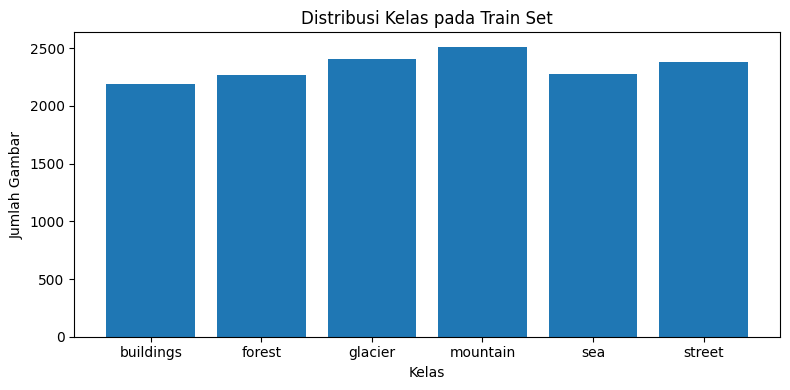

buildings   :  2191 (15.6%)
forest      :  2271 (16.2%)
glacier     :  2404 (17.1%)
mountain    :  2512 (17.9%)
sea         :  2274 (16.2%)
street      :  2382 (17.0%)


In [4]:
# Distribusi kelas pada data train
class_counts = {cls: 0 for cls in CLASS_NAMES}
for cls in CLASS_NAMES:
    class_counts[cls] = len(list(Path(TRAIN_DIR).glob(f'{cls}/*')))

plt.figure(figsize=(8, 4))
x_labels = list(class_counts.keys())
y_counts = list(class_counts.values())
plt.bar(x_labels, y_counts)
plt.title('Distribusi Kelas pada Train Set')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

total = sum(class_counts.values())
for cls, cnt in class_counts.items():
    print(f'{cls:12s}: {cnt:5d} ({cnt/total*100:.1f}%)')

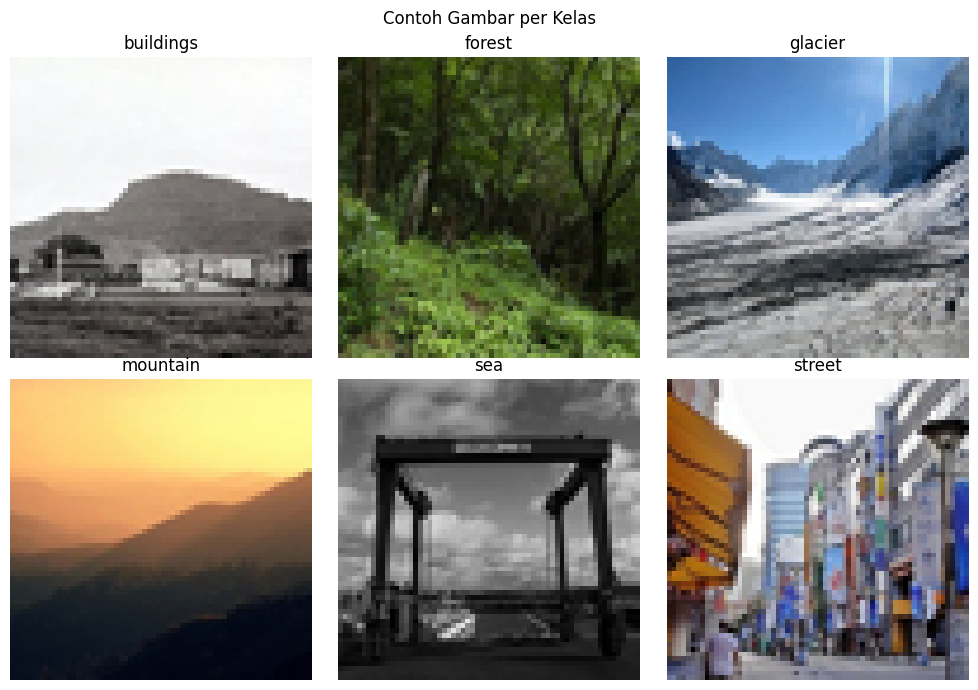

In [5]:
# Contoh gambar per kelas
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, cls in zip(axes.flat, CLASS_NAMES):
    img_path = next(Path(TRAIN_DIR).glob(f'{cls}/*.jpg'))
    img = load_image(str(img_path), target_size=IMAGE_SIZE)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.suptitle('Contoh Gambar per Kelas')
plt.tight_layout()
plt.show()

# 2. Data Cleaning and Preprocessing

In [6]:
sample_path = next(Path(TRAIN_DIR).glob('buildings/*.jpg'))
img = load_image(str(sample_path), target_size=IMAGE_SIZE)
print('Shape :', img.shape)
print('Min   :', img.min(), '  Max:', img.max())

Shape : (64, 64, 3)
Min   : 0.003921569   Max: 1.0


In [7]:
sample_paths = [str(p) for cls in CLASS_NAMES for p in list(Path(TRAIN_DIR).glob(f'{cls}/*.jpg'))[:2]]
batch = load_batch(sample_paths, target_size=IMAGE_SIZE)
print('Batch shape:', batch.shape)

Batch shape: (12, 64, 64, 3)


# 3. Modeling and Validation
## Pelatihan 16 Arsitektur
Grid hyperparameter:
- n_layers: jumlah layer konvolusi (`[2, 4]`)
- filters: filter per layer (`[[32, 64], [64, 128]]`)
- kernel_size: ukuran filter (`[3, 5]`)
- pooling: jenis pooling (`['max', 'avg']`)

In [8]:
def build_cnn(n_layers, filters, kernel_size, pooling):
    filters_ext = (filters * n_layers)[:n_layers]
    Pool = keras.layers.MaxPooling2D if pooling == 'max' else keras.layers.AveragePooling2D

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(*IMAGE_SIZE, 3)))
    for i in range(n_layers):
        model.add(keras.layers.Conv2D(filters_ext[i], kernel_size, activation='relu', padding='same'))
        if i % 2 == 1 or i == n_layers - 1:
            model.add(Pool(pool_size=2))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

def compute_macro_f1(model, dataset):
    y_true, y_pred = [], []
    for x_batch, y_batch in dataset:
        preds = np.argmax(model.predict(x_batch, verbose=0), axis=1)
        y_pred.extend(preds)
        y_true.extend(y_batch.numpy())
    return f1_score(y_true, y_pred, average='macro')

configs = []
for n_layers in [2, 4]:
    for filters in [[32, 64], [64, 128]]:
        for kernel_size in [3, 5]:
            for pooling in ['max', 'avg']:
                configs.append({'n_layers': n_layers, 'filters': filters, 'kernel_size': kernel_size, 'pooling': pooling})

print(f'Total konfigurasi: {len(configs)}')
for i, c in enumerate(configs):
    print(f'[{i:02d}] layers={c["n_layers"]}, filters={c["filters"]}, kernel={c["kernel_size"]}, pooling={c["pooling"]}')

Total konfigurasi: 16
[00] layers=2, filters=[32, 64], kernel=3, pooling=max
[01] layers=2, filters=[32, 64], kernel=3, pooling=avg
[02] layers=2, filters=[32, 64], kernel=5, pooling=max
[03] layers=2, filters=[32, 64], kernel=5, pooling=avg
[04] layers=2, filters=[64, 128], kernel=3, pooling=max
[05] layers=2, filters=[64, 128], kernel=3, pooling=avg
[06] layers=2, filters=[64, 128], kernel=5, pooling=max
[07] layers=2, filters=[64, 128], kernel=5, pooling=avg
[08] layers=4, filters=[32, 64], kernel=3, pooling=max
[09] layers=4, filters=[32, 64], kernel=3, pooling=avg
[10] layers=4, filters=[32, 64], kernel=5, pooling=max
[11] layers=4, filters=[32, 64], kernel=5, pooling=avg
[12] layers=4, filters=[64, 128], kernel=3, pooling=max
[13] layers=4, filters=[64, 128], kernel=3, pooling=avg
[14] layers=4, filters=[64, 128], kernel=5, pooling=max
[15] layers=4, filters=[64, 128], kernel=5, pooling=avg


In [9]:
results = []

for i, cfg in enumerate(configs):
    print(f'\n[{i+1:02d}/16] {cfg}')
    model = build_cnn(cfg['n_layers'], cfg['filters'], cfg['kernel_size'], cfg['pooling'])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        verbose=1,
    )
    val_f1  = compute_macro_f1(model, val_ds)
    test_f1 = compute_macro_f1(model, test_ds)
    print(f'Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')

    weight_path = str(WEIGHTS_DIR / f'model_{i:02d}.weights.h5')
    model.save_weights(weight_path)

    results.append({'id': i, 'config': cfg, 'val_f1': val_f1, 'test_f1': test_f1, 'history': history.history, 'weight_path': weight_path})

summary = [{'id': r['id'], 'config': r['config'], 'val_f1': r['val_f1'], 'test_f1': r['test_f1'], 'weight_path': r['weight_path']} for r in results]

with open(WEIGHTS_DIR / 'results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)


[01/16] {'n_layers': 2, 'filters': [32, 64], 'kernel_size': 3, 'pooling': 'max'}


351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 136ms/step - accuracy: 0.6649 - loss: 0.9044 - val_accuracy: 0.6458 - val_loss: 0.8723
Val F1: 0.6444, Test F1: 0.6441

[02/16] {'n_layers': 2, 'filters': [32, 64], 'kernel_size': 3, 'pooling': 'avg'}
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 134ms/step - accuracy: 0.6214 - loss: 1.0193 - val_accuracy: 0.6768 - val_loss: 0.8636
Val F1: 0.6717, Test F1: 0.6604

[03/16] {'n_layers': 2, 'filters': [32, 64], 'kernel_size': 5, 'pooling': 'max'}
351/351 ━━━━━━━━━━━━━━━━━━━━ 91s 256ms/step - accuracy: 0.6146 - loss: 1.0023 - val_accuracy: 0.7060 - val_loss: 0.8118
Val F1: 0.7096, Test F1: 0.7047

[04/16] {'n_layers': 2, 'filters': [32, 64], 'kernel_size': 5, 'pooling': 'avg'}
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 269ms/step - accuracy: 0.6079 - loss: 1.0254 - val_accuracy: 0.6885 - val_loss: 0.8578
Val F1: 0.6899, Test F1: 0.7062

[05/16] {'n_layers': 2, 'filters': [64, 128], 'kernel_size': 3, 'pooling': 'max'}
351/351 ━━━━━━━━━━━━━━━━━━━━ 166s 470ms/step - accuracy: 0.6260

In [10]:
print(f'{"ID":>3}  {"Layers":>6}  {"Filters":>12}  {"Kernel":>6}  {"Pooling":>7}  {"Val F1":>8}  {"Test F1":>9}')
print('-' * 65)
for r in sorted(results, key=lambda x: x['test_f1'], reverse=True):
    c = r['config']
    print(f"{r['id']:>3}  {c['n_layers']:>6}  {str(c['filters']):>12}  {c['kernel_size']:>6}  {c['pooling']:>7}  {r['val_f1']:>8.4f}  {r['test_f1']:>9.4f}")

best = max(results, key=lambda x: x['test_f1'])
print(f"\nArsitektur terbaik: [{best['id']:02d}] {best['config']} - Test F1: {best['test_f1']:.4f}")

 ID  Layers       Filters  Kernel  Pooling    Val F1    Test F1
-----------------------------------------------------------------
 12       4     [64, 128]       3      max    0.7137     0.7137
  5       2     [64, 128]       3      avg    0.7159     0.7103
  4       2     [64, 128]       3      max    0.7028     0.7080
  3       2      [32, 64]       5      avg    0.6899     0.7062
  2       2      [32, 64]       5      max    0.7096     0.7047
 13       4     [64, 128]       3      avg    0.6796     0.6767
  1       2      [32, 64]       3      avg    0.6717     0.6604
 10       4      [32, 64]       5      max    0.6760     0.6602
  6       2     [64, 128]       5      max    0.6325     0.6441
  0       2      [32, 64]       3      max    0.6444     0.6441
  9       4      [32, 64]       3      avg    0.6489     0.6438
 11       4      [32, 64]       5      avg    0.6279     0.6333
  8       4      [32, 64]       3      max    0.6246     0.6194
 15       4     [64, 128]       5     

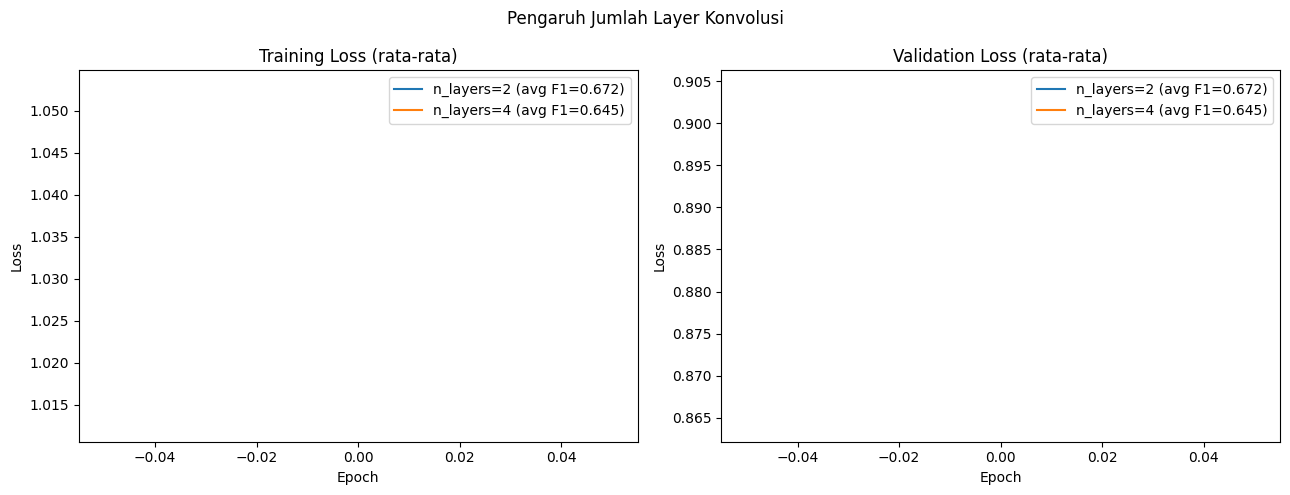

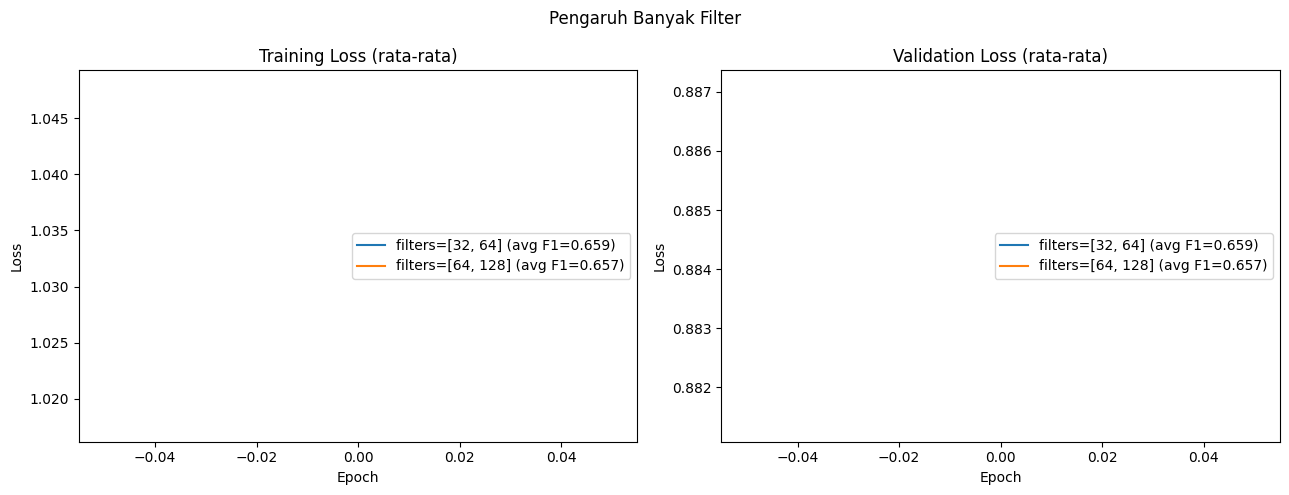

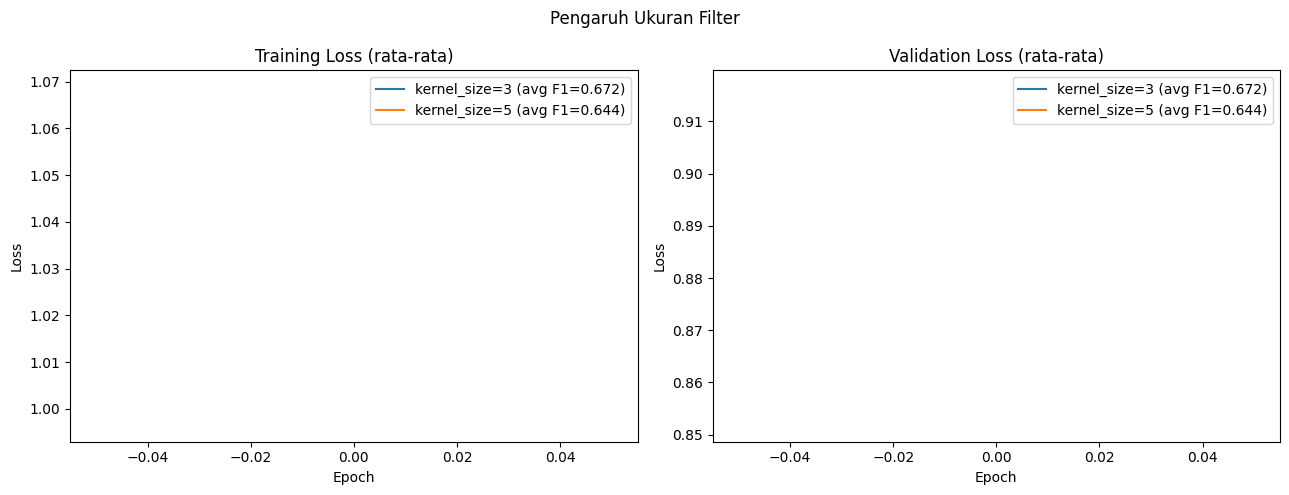

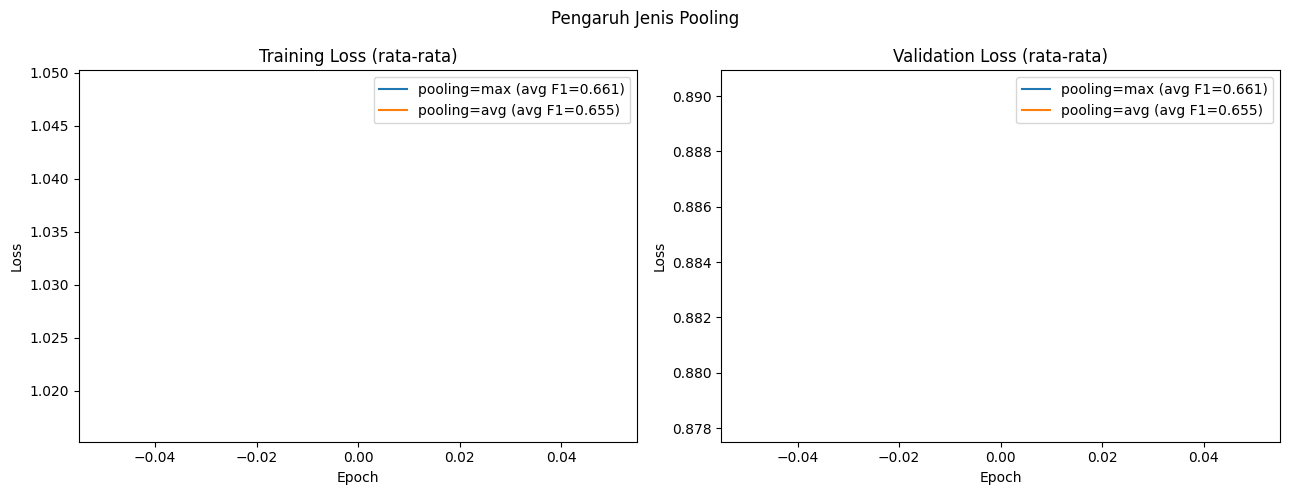

In [11]:
def plot_hp_effect(results, key, values, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for val in values:
        subset      = [r for r in results if r['config'][key] == val]
        train_losses = [r['history']['loss'] for r in subset]
        val_losses   = [r['history']['val_loss'] for r in subset]

        min_len   = min(len(l) for l in train_losses)
        avg_train = np.mean([l[:min_len] for l in train_losses], axis=0)
        avg_val   = np.mean([l[:min_len] for l in val_losses],   axis=0)
        avg_f1    = np.mean([r['test_f1'] for r in subset])

        label = f'{key}={val} (avg F1={avg_f1:.3f})'
        axes[0].plot(avg_train, label=label)
        axes[1].plot(avg_val,   label=label)

    axes[0].set_title('Training Loss (rata-rata)')
    axes[1].set_title('Validation Loss (rata-rata)')
    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_hp_effect(results, 'n_layers', [2, 4], 'Pengaruh Jumlah Layer Konvolusi')
plot_hp_effect(results, 'filters', [[32,64], [64,128]], 'Pengaruh Banyak Filter')
plot_hp_effect(results, 'kernel_size', [3, 5], 'Pengaruh Ukuran Filter')
plot_hp_effect(results, 'pooling', ['max', 'avg'], 'Pengaruh Jenis Pooling')

# 4. Error Analysis
## Bagian 4 (Eksperimen dan Evaluasi)

In [12]:
x_test = np.concatenate([x.numpy() for x, _ in test_ds], axis=0)
y_test = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
print('Test set:', x_test.shape)

Test set: (3000, 64, 64, 3)


In [13]:
best_cfg = best['config']
keras_best = build_cnn(best_cfg['n_layers'], best_cfg['filters'], best_cfg['kernel_size'], best_cfg['pooling'])
keras_best.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
keras_best.load_weights(best['weight_path'])

y_pred_keras = np.argmax(keras_best.predict(x_test, verbose=1), axis=1)
f1_keras = f1_score(y_test, y_pred_keras, average='macro')
print(f'Keras Test macro F1: {f1_keras:.4f}')

C:\Users\Grace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 205ms/step
Keras Test macro F1: 0.7137


In [14]:
def build_scratch_model(keras_model):
    layers = []
    for keras_layer in keras_model.layers:
        name = keras_layer.name
        if 'conv2d' in name and 'locally' not in name:
            w, b = keras_layer.get_weights()
            cfg  = keras_layer.get_config()
            layer = Conv2DScratch(
                filters=keras_layer.filters,
                kernel_size=keras_layer.kernel_size,
                strides=keras_layer.strides,
                padding=cfg['padding'],
                activation=cfg['activation'],
            )
            layer.kernel, layer.bias = w, b
            layers.append(layer)
        elif 'max_pooling' in name:
            layers.append(MaxPooling2DScratch(pool_size=keras_layer.pool_size, strides=keras_layer.strides))
        elif 'average_pooling' in name:
            layers.append(AveragePooling2DScratch(pool_size=keras_layer.pool_size, strides=keras_layer.strides))
        elif 'flatten' in name:
            layers.append(FlattenScratch())
        elif 'dense' in name:
            w, b = keras_layer.get_weights()
            cfg  = keras_layer.get_config()
            layer = Dense(n_neurons=keras_layer.units, activation=cfg['activation'])
            layer.weights, layer.biases = w, b
            layers.append(layer)
            
    return Sequential(layers)

scratch_model = build_scratch_model(keras_best)
scratch_model.build(x_test.shape)

y_pred_scratch = np.argmax(scratch_model.predict(x_test), axis=1)
f1_scratch = f1_score(y_test, y_pred_scratch, average='macro')
print(f'Scratch (Conv2D) Test macro F1: {f1_scratch:.4f}')
print(f'Selisih Keras dengan Scratch: {abs(f1_keras - f1_scratch):.6f}')

Scratch (Conv2D) Test macro F1: 0.7137
Selisih Keras dengan Scratch: 0.000000


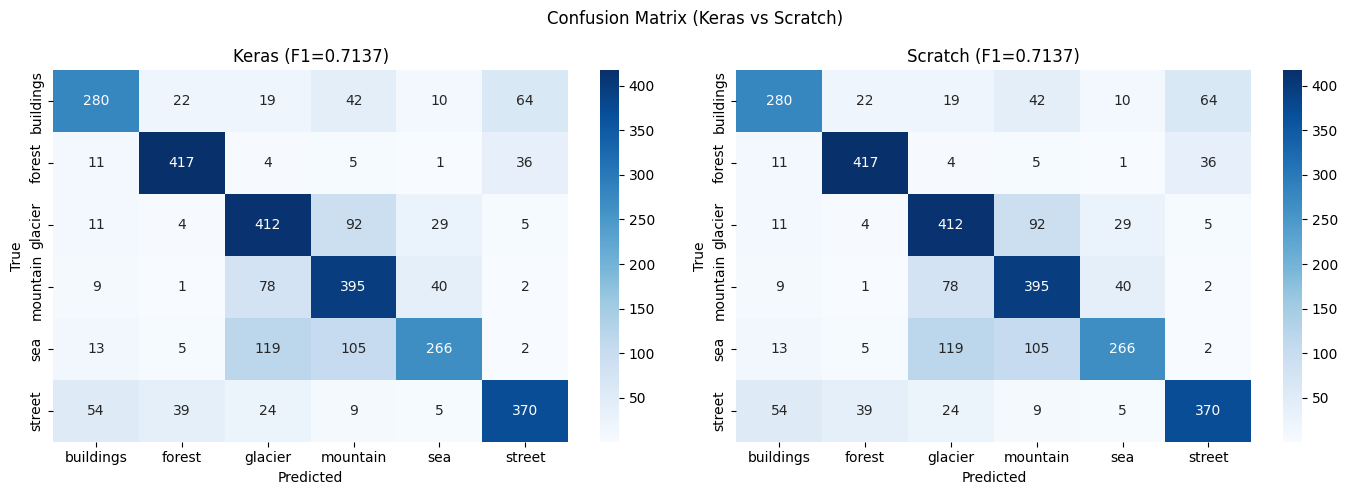

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes, [y_pred_keras, y_pred_scratch], [f'Keras (F1={f1_keras:.4f})', f'Scratch (F1={f1_scratch:.4f})']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.suptitle('Confusion Matrix (Keras vs Scratch)')
plt.tight_layout()
plt.show()

In [ ]:
import tf_keras

def build_locally_connected(n_layers, filters, kernel_size, pooling):
    filters_ext = (filters * n_layers)[:n_layers]
    Pool = tf_keras.layers.MaxPooling2D if pooling == 'max' else tf_keras.layers.AveragePooling2D
    model = tf_keras.Sequential()
    model.add(tf_keras.layers.Input(shape=(*IMAGE_SIZE, 3)))
    for i in range(n_layers):
        model.add(tf_keras.layers.LocallyConnected2D(filters_ext[i], kernel_size, activation='relu'))
        if i % 2 == 1 or i == n_layers - 1:
            model.add(Pool(pool_size=2))
    model.add(tf_keras.layers.Flatten())
    model.add(tf_keras.layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

lc_model = build_locally_connected(best_cfg['n_layers'], best_cfg['filters'], best_cfg['kernel_size'], best_cfg['pooling'])
lc_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(f'Parameter Conv2D (shared)   : {keras_best.count_params():,}')
print(f'Parameter LocallyConnected  : {lc_model.count_params():,}')

lc_history = lc_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=[tf_keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1,
)
lc_model.save_weights(str(WEIGHTS_DIR / 'model_locally_connected.weights.h5'))

y_pred_lc = np.argmax(lc_model.predict(x_test, verbose=0), axis=1)
f1_lc = f1_score(y_test, y_pred_lc, average='macro')
print(f'LocallyConnected2D Test macro F1: {f1_lc:.4f}')





Parameter Conv2D (shared)   : 419,910
Parameter LocallyConnected  : 380,679,430




In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(best['history']['loss'], label=f'Conv2D train')
axes[0].plot(lc_history.history['loss'], label=f'LocallyConnected2D train')
axes[1].plot(best['history']['val_loss'], label=f'Conv2D val')
axes[1].plot(lc_history.history['val_loss'], label=f'LocallyConnected2D val')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
axes[0].set_title('Training Loss')
axes[1].set_title('Validation Loss')
fig.suptitle('Shared (Conv2D) vs Non-Shared (LocallyConnected2D)')
plt.tight_layout()
plt.show()

print('\nPerbandingan Shared vs Non-Shared')
print(f'Conv2D (shared) - F1: {f1_keras:.4f} | params: {keras_best.count_params():>12,}')
print(f'LocallyConnected2D - F1: {f1_lc:.4f} | params: {lc_model.count_params():>12,}')
print(f'\nPerbandingan Keras vs Scratch')
print(f'Keras (Conv2D) - F1: {f1_keras:.4f}')
print(f'Scratch (Conv2D) - F1: {f1_scratch:.4f}')
print(f'Selisih : {abs(f1_keras - f1_scratch):.6f}')

NameError: name 'plt' is not defined

# Visualisasi Fitur CNN

## 1. Intermediate Feature Maps

In [ ]:
import matplotlib.pyplot as plt

sample_imgs, sample_labels = [], []
for cls_idx in range(NUM_CLASSES):
    idx = np.where(y_test == cls_idx)[0][0]
    sample_imgs.append(x_test[idx])
    sample_labels.append(y_test[idx])

img = sample_imgs[0]
label = sample_labels[0]
img_input = np.expand_dims(img, axis=0)

print(f'Visualisasi untuk kelas: {CLASS_NAMES[label]}')

conv_layer_names = [l.name for l in keras_best.layers if 'conv2d' in l.name]
feature_model = keras.Model(
    inputs=keras_best.input,
    outputs=[keras_best.get_layer(name).output for name in conv_layer_names]
)
feature_maps = feature_model.predict(img_input, verbose=0)

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f'Input: {CLASS_NAMES[label]}')
plt.axis('off')
plt.tight_layout()
plt.show()

for layer_name, fmap in zip(conv_layer_names, feature_maps):
    n_show = min(16, fmap.shape[-1])
    fig, axes = plt.subplots(2, n_show // 2, figsize=(16, 4))
    fig.suptitle(f'Feature Maps {layer_name} ({fmap.shape[-1]} filters, menampilkan {n_show})')
    for idx, ax in enumerate(axes.flat):
        ax.imshow(fmap[0, :, :, idx], cmap='viridis')
        ax.set_title(f'f{idx}', fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 2. Grad-CAM

In [ ]:
import matplotlib.cm as cm

def compute_gradcam(model, img_array, class_idx=None):
    last_conv_name = [l.name for l in model.layers if 'conv2d' in l.name][-1]

    grad_model = keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        class_score = predictions[:, class_idx]

    grads = tape.gradient(class_score, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0].numpy()
    pooled_grads = pooled_grads.numpy()
    heatmap = np.dot(conv_output, pooled_grads)
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap, int(class_idx)


def overlay_gradcam(img, heatmap, alpha=0.4):
    H, W = img.shape[:2]
    heatmap_resized = np.array(
        tf.image.resize(heatmap[..., np.newaxis], (H, W))
    ).squeeze()
    colormap = cm.get_cmap('jet')
    heatmap_colored = colormap(heatmap_resized)[:, :, :3]
    overlay = (1 - alpha) * img + alpha * heatmap_colored
    return np.clip(overlay, 0, 1)


fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(10, NUM_CLASSES * 3))
fig.suptitle('Grad-CAM', fontsize=13)

for cls_idx, (img, label) in enumerate(zip(sample_imgs, sample_labels)):
    img_input = np.expand_dims(img, axis=0).astype(np.float32)

    heatmap, pred_class = compute_gradcam(keras_best, img_input, class_idx=label)
    overlay = overlay_gradcam(img, heatmap)

    axes[cls_idx, 0].imshow(img)
    axes[cls_idx, 0].set_title(f'Input: {CLASS_NAMES[label]}', fontsize=8)
    axes[cls_idx, 0].axis('off')

    axes[cls_idx, 1].imshow(heatmap, cmap='jet')
    axes[cls_idx, 1].set_title('Heatmap', fontsize=8)
    axes[cls_idx, 1].axis('off')

    axes[cls_idx, 2].imshow(overlay)
    axes[cls_idx, 2].set_title('Overlay', fontsize=8)
    axes[cls_idx, 2].axis('off')

plt.tight_layout()
plt.show()